## SHAP: Shapley Additive Explanations for Feature Importance

**SHAP is a explanative machine learning model built upon game theories, clarifying how a model makes decision by analyzing the contribution of each feature more correctly.**

SHAP is a method that provides us the best insight on which features in the dataset strongly or negatively affect the prediction. SHAP is a powerful tool that helps us see which parts of our data matter the most in making predictions, working with every ML model (from linear, tree-based model, to ensemble model).

SHAP replaces the original feature importance to gives us a much better interpretation on which feature actually contribute the most to the model training and prediction, especially when the features are encoded with One-Hot Encoding.

When working with machine learning models, especially tree-based models such as Random Forest, Gradient Boosting, XGBoost, and LightGBM, one of the most commonly inspected diagnostics is **feature importance**. It gives us a sense of which features the model relies on the most when making predictions.

However, a subtle but significant issue often appears when we apply **One-Hot Encoding** to categorical features. This encoding method transforms a single categorical variable into multiple binary columns, one for each category. Although this is necessary for most algorithms, it can distort how we interpret feature importance.

More details: https://dune-web-e44.notion.site/SHAP-Shapley-Additive-Explanations-2c5622d6055680c087bddb57e23de156?pvs=74

Reference: https://www.geeksforgeeks.org/machine-learning/shap-a-comprehensive-guide-to-shapley-additive-explanations/

Read the dataframe:

Dataset link: https://github.com/MalongSuper/My-Python-Programming/blob/b47281294a67022eac00a0629580001ab2194814/Python-Data%20Visualization/dav_datasets/car_dataset.csv

In [115]:
import pandas as pd

df = pd.read_csv("car_dataset.csv")
df

,Age,Income,Color,Car_Type,Mileage,Purchased
0,25,40000,Red,SUV,65000,0
1,45,90000,Black,Sedan,20000,1
2,32,55000,Blue,SUV,43000,1
3,29,50000,Red,Truck,80000,0
4,50,110000,Black,SUV,18000,1
...,...,...,...,...,...,...
505,42,61699,Blue,SUV,29874,1
506,26,119385,Black,SUV,75799,1
507,35,87283,Blue,Sedan,22425,1
508,28,53649,Red,SUV,35104,1


In [116]:
df.describe(include='all').fillna('no info')

,Age,Income,Color,Car_Type,Mileage,Purchased
count,510.0,510.0,510,510,510.0,510.0
unique,no info,no info,4,3,no info,no info
top,no info,no info,Black,SUV,no info,no info
freq,no info,no info,151,244,no info,no info
mean,37.001961,70654.919608,no info,no info,46277.805882,0.907843
std,9.570645,26488.271114,no info,no info,22875.590227,0.289531
min,20.0,20000.0,no info,no info,5000.0,0.0
25%,30.0,52582.25,no info,no info,30481.25,1.0
50%,37.0,70235.0,no info,no info,45949.5,1.0
75%,43.0,87629.25,no info,no info,62068.25,1.0


One-Hot Encoding:

In [117]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["Color", "Car_Type"]).replace({True: 1, False: 0})
df_encoded

/tmp/ipython-input-1043515246.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = pd.get_dummies(df, columns=["Color", "Car_Type"]).replace({True: 1, False: 0})


,Age,Income,Mileage,Purchased,Color_Black,Color_Blue,Color_Green,Color_Red,Car_Type_SUV,Car_Type_Sedan,Car_Type_Truck
0,25,40000,65000,0,0,0,0,1,1,0,0
1,45,90000,20000,1,1,0,0,0,0,1,0
2,32,55000,43000,1,0,1,0,0,1,0,0
3,29,50000,80000,0,0,0,0,1,0,0,1
4,50,110000,18000,1,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
505,42,61699,29874,1,0,1,0,0,1,0,0
506,26,119385,75799,1,1,0,0,0,1,0,0
507,35,87283,22425,1,0,1,0,0,0,1,0
508,28,53649,35104,1,0,0,0,1,1,0,0


Training the model:

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Training and Testing
train_df, test_df = train_test_split(df_encoded, test_size=0.3, random_state=42)
target = 'Purchased'
features = df_encoded.columns.drop(target)
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Train the model with Gradient Boosting
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")
print(f"Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8954248366013072
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.20      0.27        15
           1       0.92      0.97      0.94       138

    accuracy                           0.90       153
   macro avg       0.67      0.59      0.61       153
weighted avg       0.87      0.90      0.88       153



- import shap: Imports the SHAP library for model interpretation.
- explainer = shap.Explainer(model): Creates a SHAP explainer for the trained model.
- shap_values = explainer(X_test): Computes SHAP values for the test data to explain predictions.
- shap.initjs(): Initializes JavaScript support for SHAP visualizations in notebooks.

In [89]:
!pip install shap

In [119]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
ret = shap.initjs()
type(ret)

NoneType

SHAP (SHapley Additive exPlanations) has a variety of visualization tools that help interpret machine learning model predictions. These plots highlight which features are important and also explain how they influence individual or overall model outputs. Below are some commonly used SHAP visualizations and what they reveal about model behavior:

- Waterfall Model: Shows how each feature contributes to the difference between the model's base value and the output prediction for a specific instance.

Color Guide:

- Red = pushes prediction higher
- Blue = pushes prediction lower

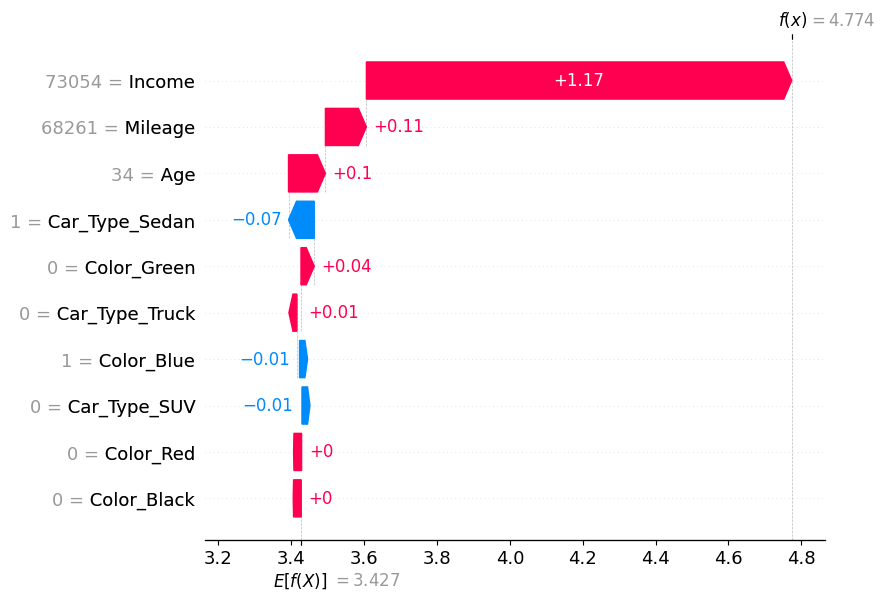

In [120]:
shap.waterfall_plot(shap_values[0])

- Force Plot: Gives an interactive view of individual prediction explanations.

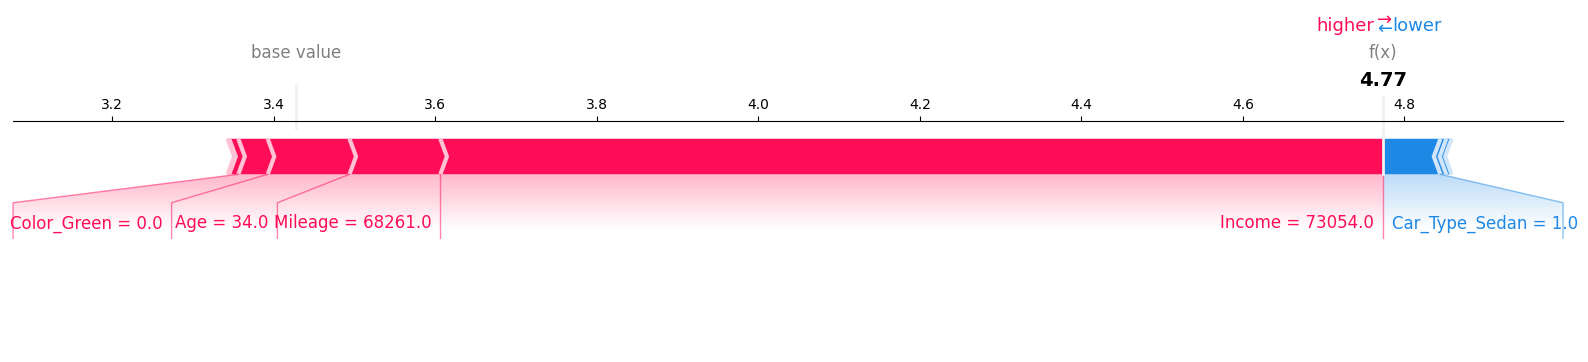

In [121]:
shap.force_plot(explainer.expected_value, shap_values[0].values, X_test.iloc[0, :], matplotlib=True)

- Stacked Force Plot: Visualizes feature contributions across multiple observations.

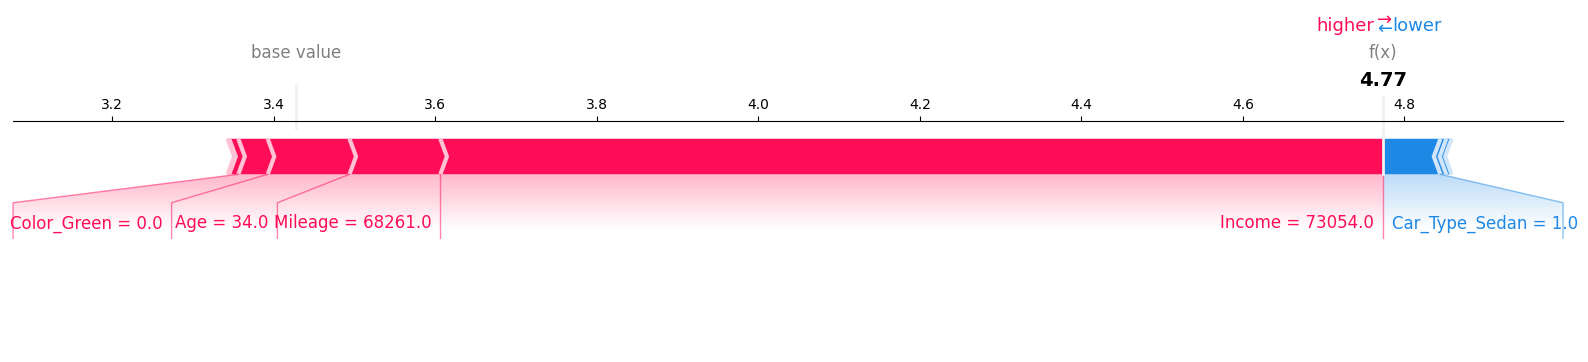

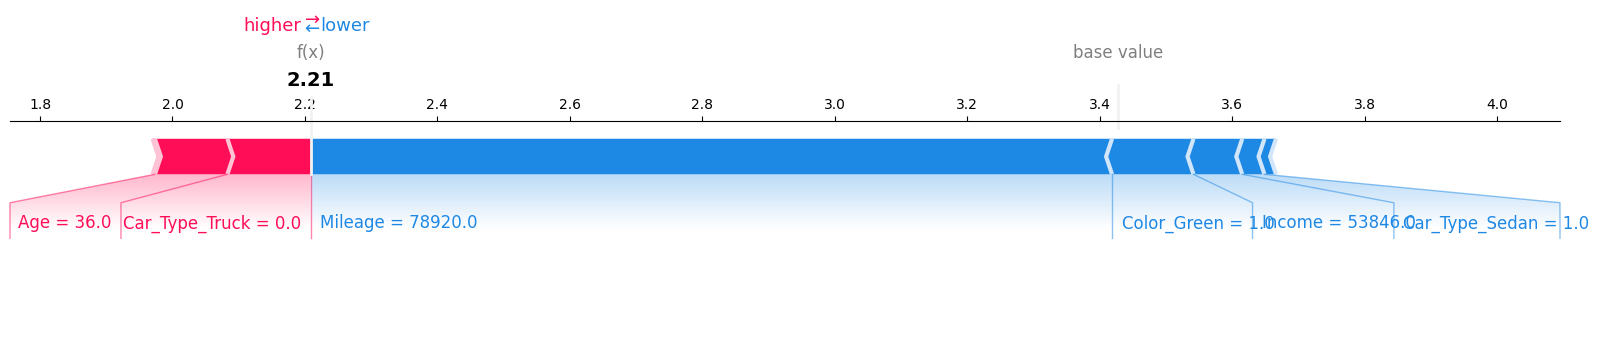

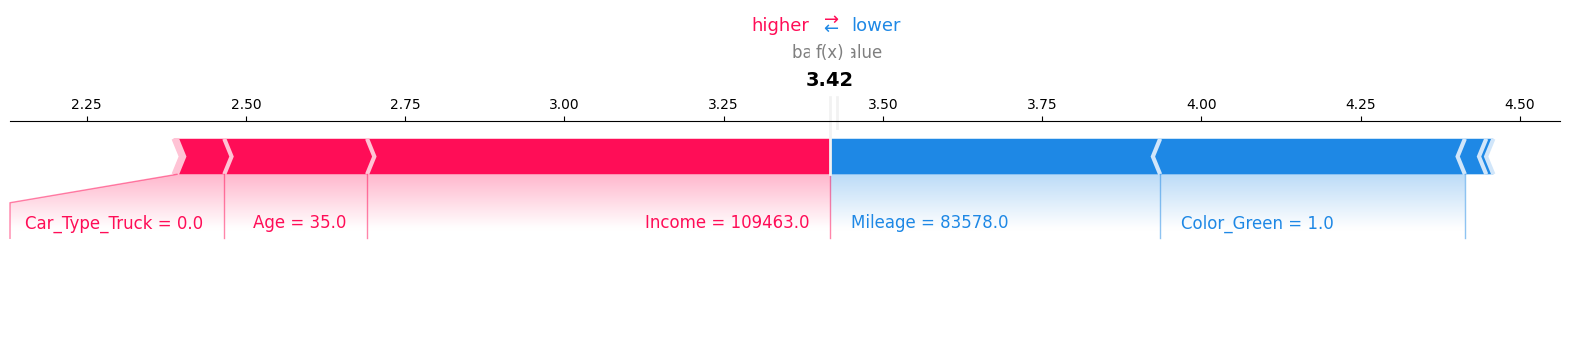

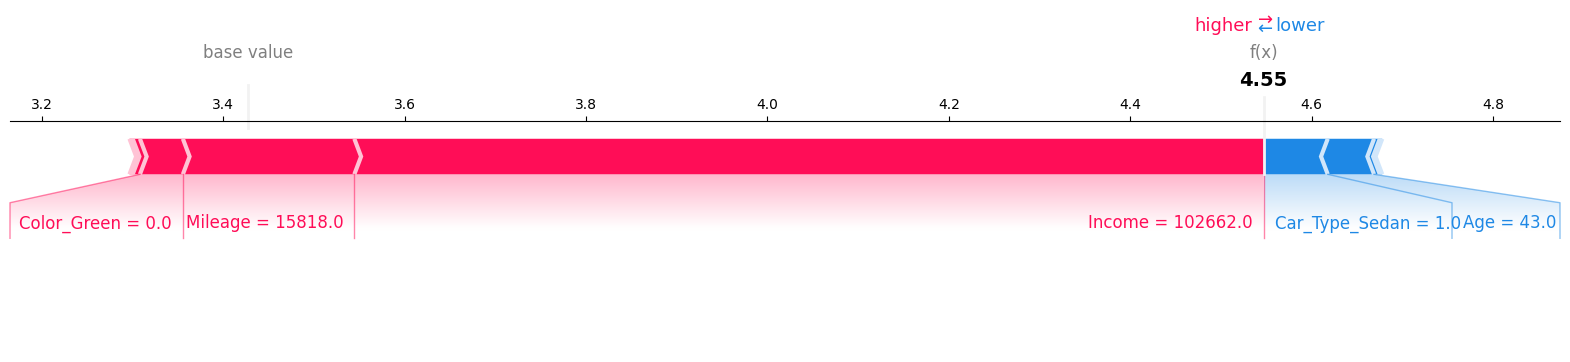

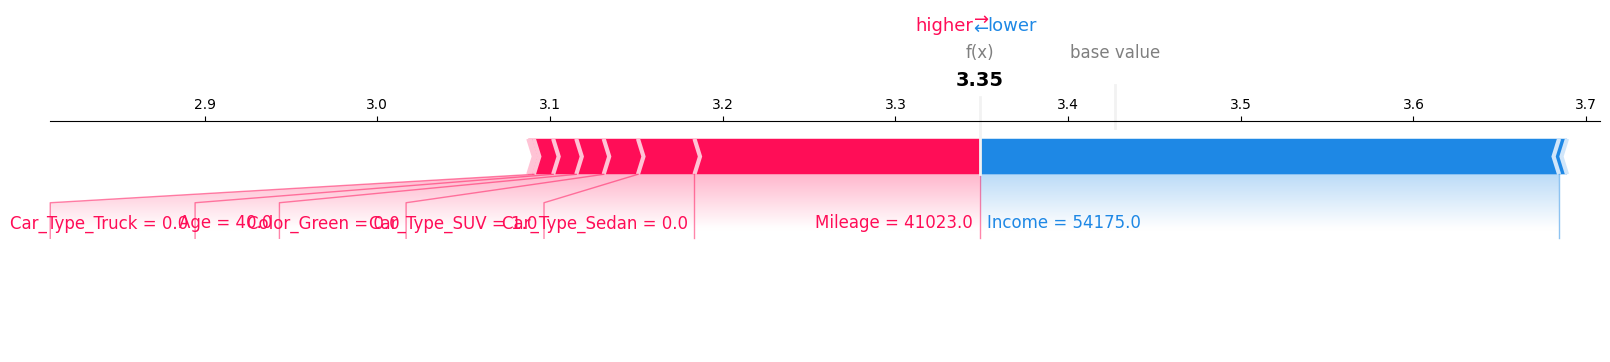

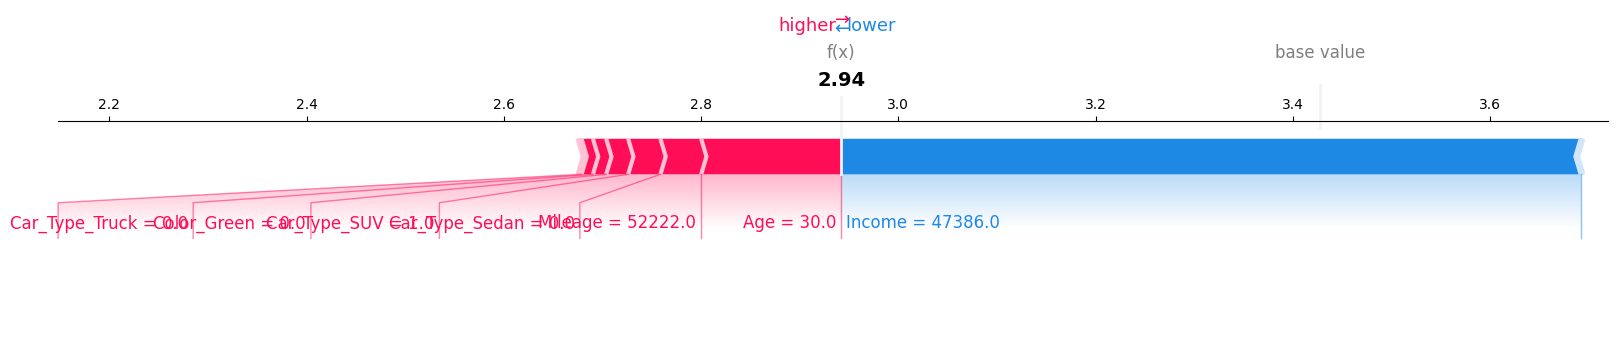

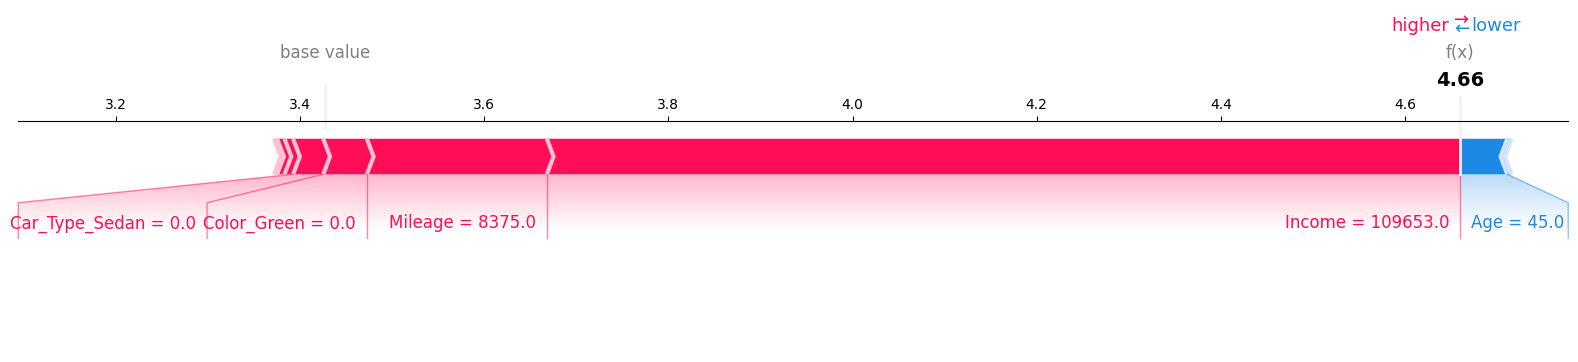

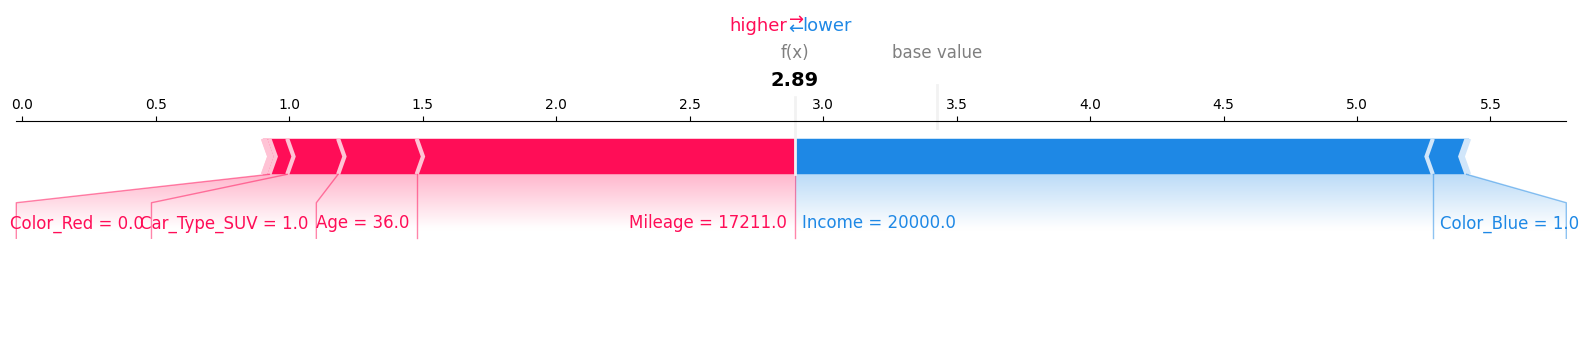

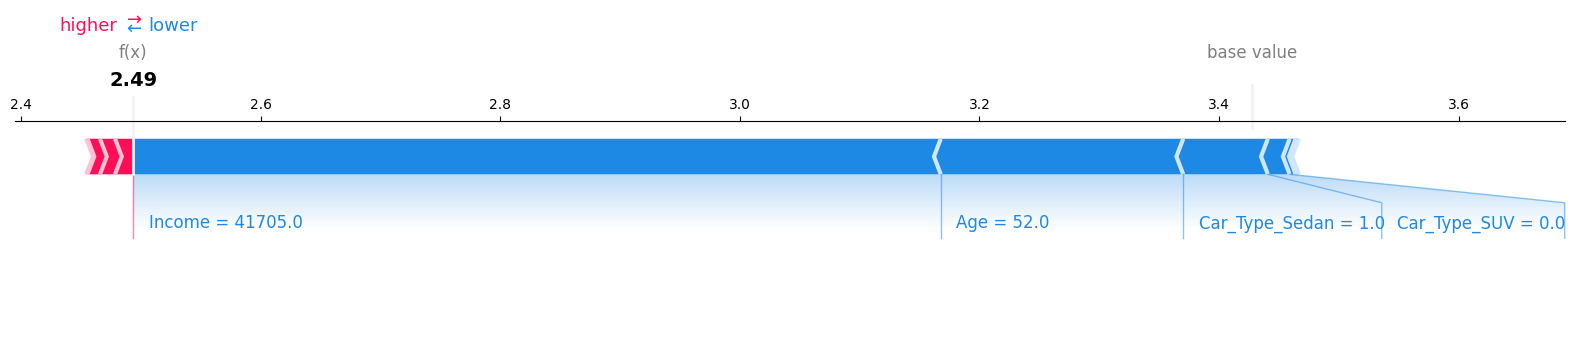

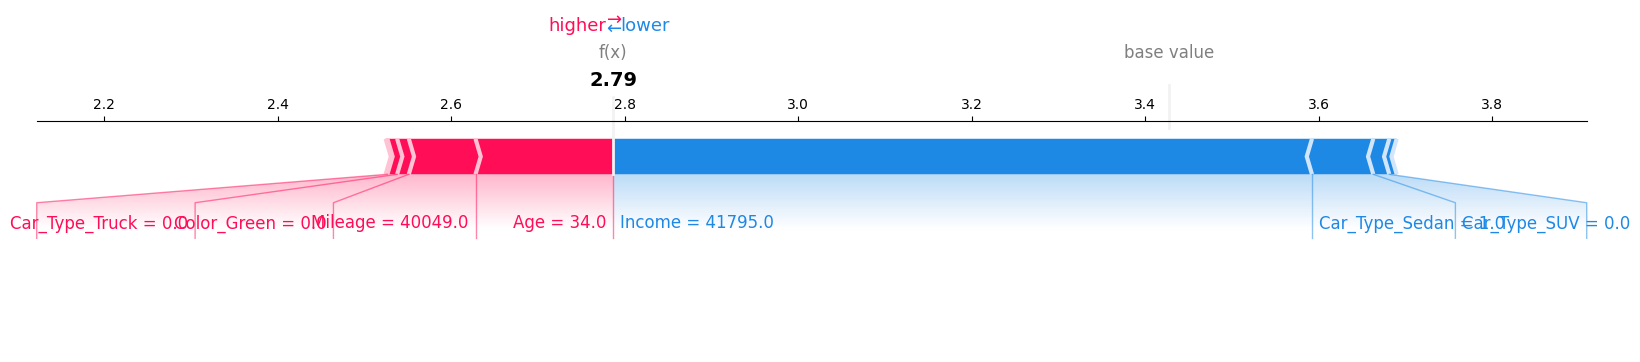

In [122]:
for i in range(10):
    shap.force_plot(explainer.expected_value, shap_values[i].values,
                    X_test.iloc[i, :], matplotlib=True)

- Summary Plot: Gives a global view of feature importance and how values influence predictions.

- Horizontal location shows whether the effect of that value is associated with a higher or lower prediction.
- Color represents the original value of the feature.

/tmp/ipython-input-2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


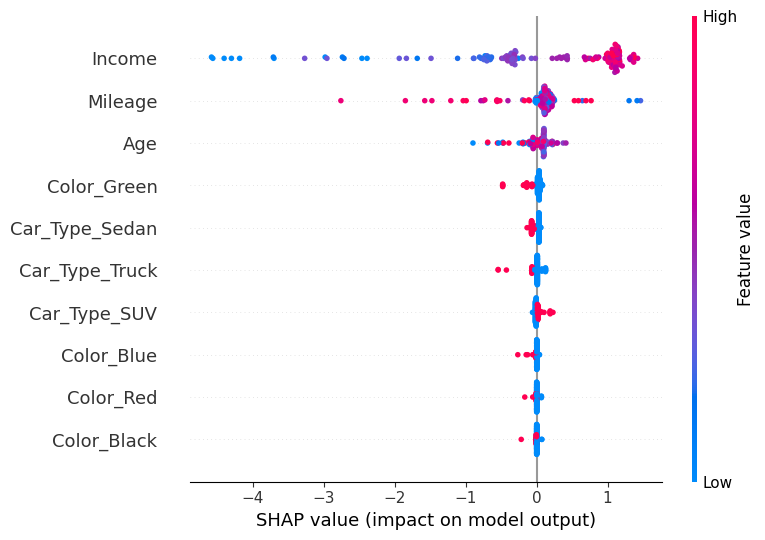

In [123]:
shap.summary_plot(shap_values, X_test)

- Bar Plot of Mean SHAP Values: Displays average feature impact across the dataset.

This is helpful when identifying which features are generally more important.

/tmp/ipython-input-3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


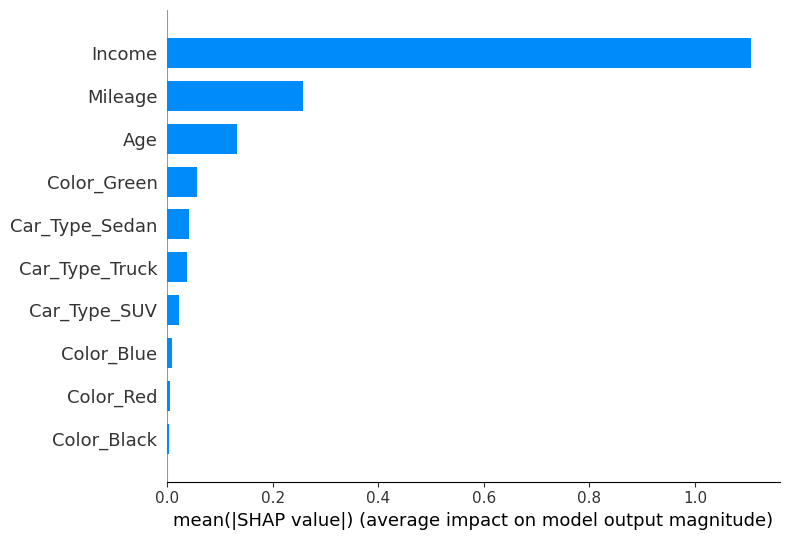

In [124]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

Feature Importance with SHAP

In [125]:
# --- SHAP Feature Importance (Table Output) ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary in table form (mean absolute SHAP values)
shap_importance = pd.DataFrame({
    "Feature": features,
    "SHAP Importance": abs(shap_values).mean(axis=0)
}).sort_values("SHAP Importance", ascending=False)

print("\nSHAP Feature Importance Table:")
print(shap_importance)


SHAP Feature Importance Table:
          Feature  SHAP Importance
1          Income         1.105688
2         Mileage         0.256555
0             Age         0.132399
5     Color_Green         0.056136
8  Car_Type_Sedan         0.041406
9  Car_Type_Truck         0.037501
7    Car_Type_SUV         0.022524
4      Color_Blue         0.008734
6       Color_Red         0.006209
3     Color_Black         0.004544


Interpretation

- **Income dominates the model:** Income is overwhelmingly the most important feature. The model relies heavily on financial capability to determine whether a customer can or will purchase.
- **Mileage and Age are meaningful secondary factors:** These affect perceived value and customer affordability.
- **Colors contribute very little:** Once One-Hot Encoding is applied, color variables become separate binary columns—none stand out strongly. SHAP makes this clear by showing their small effect.
- **Car types matter, but not significantly:** Sedan, Truck, and SUV have measurable but relatively small roles. This suggests car body style alone does not drive the final decision

When SHAP values are computed after One-Hot Encoding, each dummy column receives its own SHAP importance.

To recover the importance of the *original* categorical feature, we must combine all SHAP values belonging to the same group.

In [126]:
# Aggregate the SHAP Importance of Car Type
car_type = shap_importance[shap_importance['Feature'].str.startswith('Car_Type')]
# Add this row
shap_importance.loc[len(shap_importance)] = ['Car_Type', car_type['SHAP Importance'].sum()]
# Drop the OHE Car_Type rows
shap_importance = shap_importance.drop(car_type.index)

In [127]:
# Same for Color
color = shap_importance[shap_importance['Feature'].str.startswith('Color')]
shap_importance.loc[len(shap_importance)] = ['Color', color['SHAP Importance'].sum()]
shap_importance = shap_importance.drop(color.index)
shap_importance.set_index('Feature')

,SHAP Importance
Feature,
Income,1.105688
Mileage,0.256555
Age,0.132399
Car_Type,0.101431
Color,0.075623


In [128]:
print(shap_importance.set_index('Feature'))

          SHAP Importance
Feature                  
Income           1.105688
Mileage          0.256555
Age              0.132399
Car_Type         0.101431
Color            0.075623


### Final Interpretation:

- **Income remains the most critical feature**
    - Whether looking at the detailed table or the aggregated table, **Income clearly dominates the model’s decision-making.**
    - It is far ahead of all other features in SHAP importance (1.105688).
    - This tells us that **the model relies strongly on a buyer’s income** when predicting a car purchase.
- **Mileage and Age follow next**
    - These two numerical features consistently appear in the same rank order.
    - Both maintain their relative importance in individual and aggregated results.
- **One-Hot Encoded Categories behave differently when grouped:** In the detailed table, some categories appear more important than others:
    - **Color_Green** is the strongest among color sub-features.
    - **Car_Type_Sedan** is the strongest within the car types.

But w**hen aggregated, the picture changes:**

- **Car_Type** as a group contributes more than any individual car type does.
- **Color** as a group is still the least important overall, even though some individual colors (like Green) appeared influential.

Because **One-Hot Encoding splits one feature into many binary features**, each receiving a small portion of the importance. Individually: Each color may look weak, but one or two stand out (e.g., Color_Green). Aggregated: We see the *true* contribution of the original feature.

This solves the common issue where one-hot encoded features appear artificially important or unimportant when viewed separately.